# Part 1

In [9]:
import pandas as pd

X = pd.read_csv('gene_expression.csv', sep=';', decimal=',', header=None)

y = pd.read_csv('label.csv', sep=';', header=None)

print("Rozměry X:", X.shape)
print("Rozměry y:", y.shape)

Rozměry X: (72, 7129)
Rozměry y: (72, 1)


Trénovací přesnost: 100.0 %


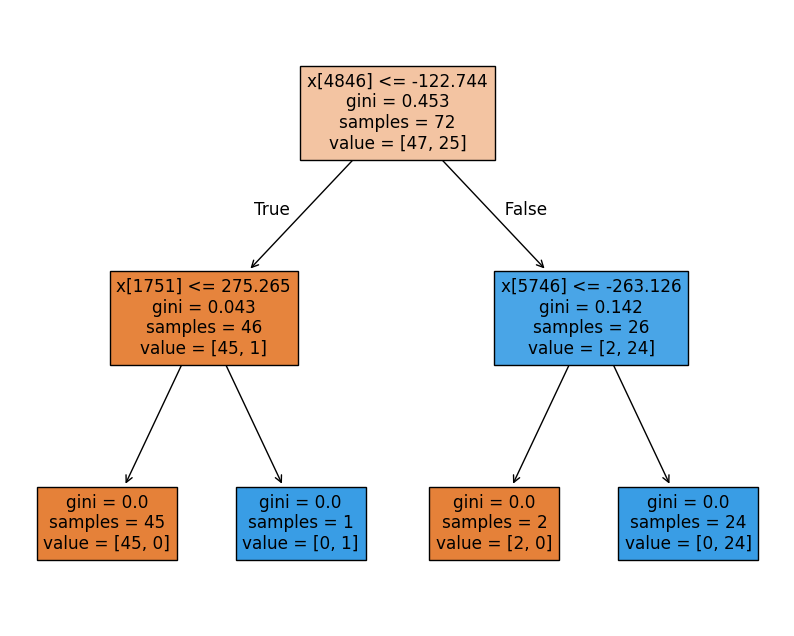

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X, y)

train_acc = tree_clf.score(X, y)
print(f"Trénovací přesnost: {train_acc * 100} %")

plt.figure(figsize=(10, 8))
plot_tree(tree_clf, filled=True)
plt.show()
# 100% přesnost mám z důvodu overfitingu moc přízanků

In [10]:
# Načtení názvů genů a zjištění jména klíčového genu
with open('geneNames.txt', 'r') as f:
    gene_names = f.readlines()

# V Pythonu se indexuje od 0, takže index 4846 odpovídá genu na řádku 4846
klicovy_gen = gene_names[4846].strip()
print(f"Klíčový gen na indexu 4846 je: {klicovy_gen}")

Klíčový gen na indexu 4846 je: ZYX


In [ ]:
# Testování reálné přesnosti pomocí cross-validace
from sklearn.model_selection import cross_val_score
import numpy as np

# Bod 5: 5-fold cross validation
# Model se 5x natrénuje na 80% dat a otestuje na zbylých 20%
cv_scores = cross_val_score(tree_clf, X, y, cv=5)
real_acc = np.mean(cv_scores)

print(f"Trénovací přesnost: {train_acc * 100:.2f} %")
print(f"Reálná přesnost (Cross-validation): {real_acc * 100:.2f} %")

Trénovací přesnost: 100.00 %
Reálná přesnost (Cross-validation): 76.38 %


In [ ]:
# zkoušíme na kolik vlastností můžeme to zmenšit pomocí PCA
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Zkusíme několik různých počtů komponent (K)
K_values = [2, 3, 4, 5, 10, 15]

print("Výsledky pro různý počet komponent K:")
print("-" * 80)

for k in K_values:
    # 1. a 2a. PCA: naučení matice V a redukce dat X na Z
    pca = PCA(n_components=k, random_state=42)
    Z = pca.fit_transform(X)
    
    # 2b. Vytvoření stromu nad zredukovanými daty Z
    tree_pca = DecisionTreeClassifier(random_state=42)
    tree_pca.fit(Z, y)
    
    # Výpočty přesností a struktury
    train_acc = tree_pca.score(Z, y)
    cv_scores = cross_val_score(tree_pca, Z, y, cv=5)
    cv_acc = np.mean(cv_scores)
    
    depth = tree_pca.get_depth()
    leaves = tree_pca.get_n_leaves()
    
    print(f"K = {k:2d} | Trénovací přesnost: {train_acc*100:6.2f} % | CV přesnost: {cv_acc*100:6.2f} % | Hloubka: {depth} | Listy: {leaves}")
    # nejlepe vycházejí dva super příznaky 

Výsledky pro různý počet komponent K:
--------------------------------------------------------------------------------
K =  2 | Trénovací přesnost: 100.00 % | CV přesnost:  94.48 % | Hloubka: 4 | Listy: 7
K =  3 | Trénovací přesnost: 100.00 % | CV přesnost:  93.14 % | Hloubka: 4 | Listy: 7
K =  4 | Trénovací přesnost: 100.00 % | CV přesnost:  93.14 % | Hloubka: 4 | Listy: 7
K =  5 | Trénovací přesnost: 100.00 % | CV přesnost:  87.43 % | Hloubka: 4 | Listy: 7
K = 10 | Trénovací přesnost: 100.00 % | CV přesnost:  84.57 % | Hloubka: 4 | Listy: 7
K = 15 | Trénovací přesnost: 100.00 % | CV přesnost:  87.43 % | Hloubka: 5 | Listy: 8



Model pro K = 2
Trénovací přesnost pro K=2: 100.00 %


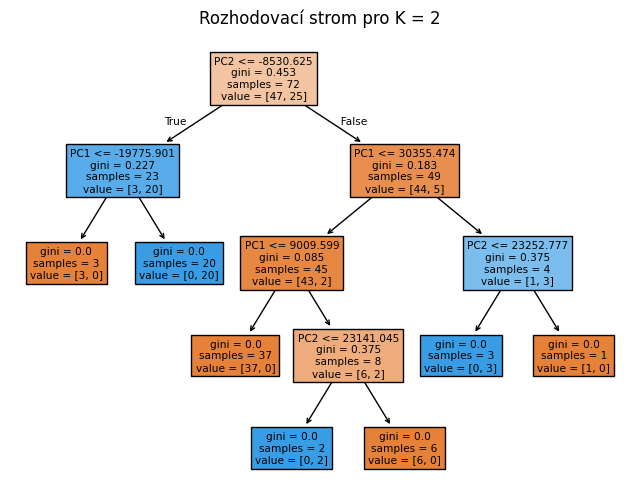


Model pro K = 3
Trénovací přesnost pro K=3: 100.00 %


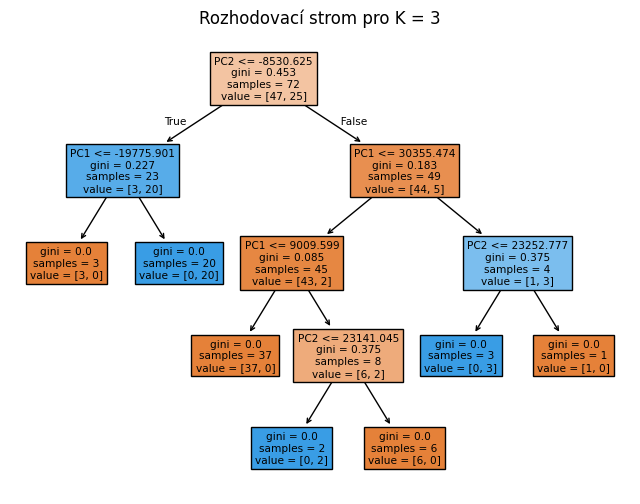


Model pro K = 5
Trénovací přesnost pro K=5: 100.00 %


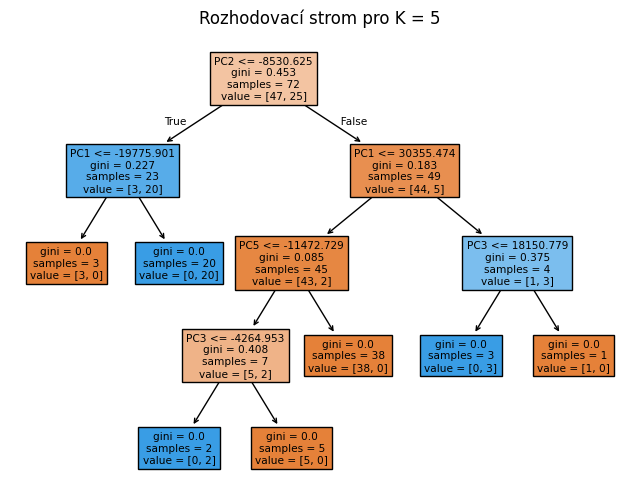


Model pro K = 10
Trénovací přesnost pro K=10: 100.00 %


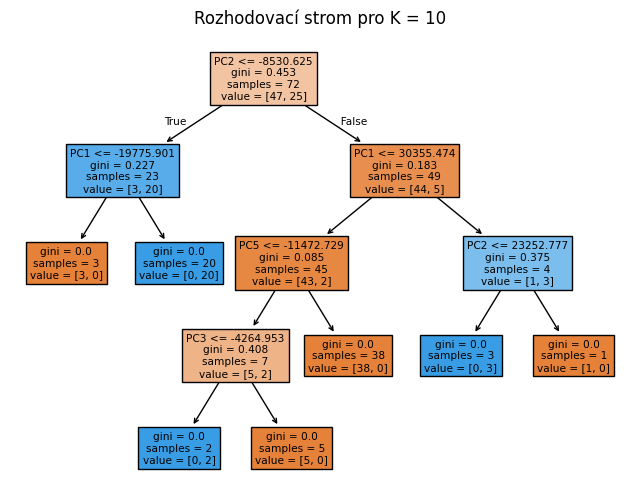

In [ ]:
# zobrazuje vnitřní rozhodování 
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Zvolíme rozsah komponent K
K_values = [2, 3, 5, 10]

# Bod 1: Naučení matice V (PCA) na celých datech
pca_full = PCA(random_state=42)
pca_full.fit(X) # Tímto krokem se model naučí bázové vektory (matici V)

# Bod 2: Cyklus přes vybraná K
for k in K_values:
    print(f"\n" + "="*40)
    print(f"Model pro K = {k}")
    
    # a. Projekce dat X do top K komponent -> vzniknou data Z
    # Vezmeme si transformovaná data a ořízneme je jen na prvních 'k' sloupců
    Z = pca_full.transform(X)[:, :k]
    
    # b. Vytvoření stromu z redukovaných dat Z
    tree_pca = DecisionTreeClassifier(random_state=42)
    tree_pca.fit(Z, y)
    
    # Vypsání trénovací přesnosti
    train_acc = tree_pca.score(Z, y)
    print(f"Trénovací přesnost pro K={k}: {train_acc * 100:.2f} %")
    
    # Vykreslení stromu ("Show it")
    plt.figure(figsize=(8, 6))
    plot_tree(tree_pca, filled=True, feature_names=[f"PC{i+1}" for i in range(k)])
    plt.title(f"Rozhodovací strom pro K = {k}")
    plt.show()

In [12]:
# vybírám nejlepší příznak
from sklearn.model_selection import cross_val_score
import numpy as np

print("Porovnání modelů pro výběr toho nejlepšího:")
print("-" * 65)

for k in K_values:
    # Připravíme data pro dané K
    Z = pca_full.transform(X)[:, :k]
    
    # Vytvoříme strom
    tree_pca = DecisionTreeClassifier(random_state=42)
    tree_pca.fit(Z, y)
    
    # Zjistíme složitost (strukturu) stromu
    hloubka = tree_pca.get_depth()
    listy = tree_pca.get_n_leaves()
    
    # Bod 4: Odhad reálné přesnosti pomocí 5-fold cross-validace
    cv_scores = cross_val_score(tree_pca, Z, y, cv=5)
    realna_presnost = np.mean(cv_scores) * 100
    
    print(f"K = {k:2d} | Reálná přesnost (CV): {realna_presnost:5.2f} % | Hloubka: {hloubka} | Počet listů: {listy}")

Porovnání modelů pro výběr toho nejlepšího:
-----------------------------------------------------------------
K =  2 | Reálná přesnost (CV): 94.48 % | Hloubka: 4 | Počet listů: 7
K =  3 | Reálná přesnost (CV): 93.14 % | Hloubka: 4 | Počet listů: 7
K =  4 | Reálná přesnost (CV): 93.14 % | Hloubka: 4 | Počet listů: 7
K =  5 | Reálná přesnost (CV): 87.43 % | Hloubka: 4 | Počet listů: 7
K = 10 | Reálná přesnost (CV): 84.57 % | Hloubka: 4 | Počet listů: 7
K = 15 | Reálná přesnost (CV): 87.43 % | Hloubka: 5 | Počet listů: 8


In [ ]:
# vybírám jenom ty nejdůležitější příznaky
from sklearn.cluster import KMeans
import numpy as np

# Znovu načteme názvy genů
with open('geneNames.txt', 'r') as f:
    gene_names = [line.strip() for line in f.readlines()]

# Vytáhneme si váhy všech 7129 genů pro první hlavní komponentu (PC1)
# pca_full jsme vytvořili v předchozím kroku
pc1_vahy = pca_full.components_[0].reshape(-1, 1)

# Aplikujeme K-means shlukování se 3 shluky (n_init pro potlačení varování)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pc1_vahy)

# Zjistíme centroidy (středy) jednotlivých shluků
centroidy = kmeans.cluster_centers_

# Vybereme ten shluk, jehož střed je nejdál od nuly (má největší absolutní hodnotu)
nejvlivnejsi_shluk_idx = np.argmax(np.abs(centroidy))

# Získáme indexy a následně jména genů, které do tohoto shluku patří
aktivni_geny_indexy = np.where(clusters == nejvlivnejsi_shluk_idx)[0]
aktivni_geny = [gene_names[i] for i in aktivni_geny_indexy]

print(f"Celkový počet genů v datech: {len(gene_names)}")
print(f"Počet 'aktivních' genů v komponentě PC1: {len(aktivni_geny)}")

# 1. Uložíme aktivní geny do souboru (Target)
with open('target_genes.txt', 'w') as f:
    for gen in aktivni_geny:
        f.write(gen + '\n')

# 2. Uložíme všechny geny do souboru pro porovnání (Background)
with open('background_genes.txt', 'w') as f:
    for gen in gene_names:
        f.write(gen + '\n')

print("Hotovo! Soubory 'target_genes.txt' a 'background_genes.txt' byly vytvořeny ve tvé složce.")

Celkový počet genů v datech: 7129
Počet 'aktivních' genů v komponentě PC1: 48
Hotovo! Soubory 'target_genes.txt' a 'background_genes.txt' byly vytvořeny ve tvé složce.


Červené boxy představují biologické procesy (např. buněčné dělení), které jsou statisticky nejvýznamnější pro odlišení AML od ALL.(nemoci)